# Multi-Directional SPAM Feature Extraction for Enhanced LSB Steganalysis

## 1. Imports & Setup

In [1]:
import json, pickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import time
from imageio.v2 import imread
from scipy.stats import ttest_rel
from skimage.feature import graycomatrix, graycoprops
from skimage.transform import resize as sk_resize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score
)
from sklearn.model_selection import (
    StratifiedGroupKFold, GroupShuffleSplit,
    train_test_split, GridSearchCV
)
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from statsmodels.stats.contingency_tables import mcnemar
from tqdm import tqdm

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

SAVE_DIR = '/kaggle/working/saved'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Save directory: {SAVE_DIR}')
print('Libraries imported successfully!')

Save directory: /kaggle/working/saved
Libraries imported successfully!


## 2. Dataset Configuration

In [2]:
BASE       = '/kaggle/input/datasets/vibhor2003/bossbaselsb/bossbase'
COVER_DIR  = os.path.join(BASE, 'cover')
PAYLOADS   = [0.2, 0.3, 0.4, 0.5]
STEGO_DIRS = {p: os.path.join(BASE, f'stego_{p}') for p in PAYLOADS}
STEGO_DIRS[0.1] = '/kaggle/input/datasets/vibhor2003/bossbaselsb/stego_0.1/stego_0.1'
STEGO_DIRS = dict(sorted(STEGO_DIRS.items()))
PAYLOADS.insert(0, 0.1)
print(PAYLOADS)

if os.path.exists(COVER_DIR):
    cover_files = sorted(os.listdir(COVER_DIR))
    print(f'Cover images: {len(cover_files)}')
    
    for p, d in STEGO_DIRS.items():
        status = 'OK' if os.path.exists(d) else 'MISSING — create stego directory'
        print(f'  stego_{p}: {status}')
        print(f'Stego images: {len(sorted(os.listdir(d)))}')
else:
    cover_files = []
    print('WARNING: COVER_DIR not found. Update BASE path.')

[0.1, 0.2, 0.3, 0.4, 0.5]
Cover images: 10000
  stego_0.1: OK
Stego images: 10000
  stego_0.2: OK
Stego images: 10000
  stego_0.3: OK
Stego images: 10000
  stego_0.4: OK
Stego images: 10000
  stego_0.5: OK
Stego images: 10000


## 3. Feature Extraction Functions
### 3.1 Preprocessing

In [3]:
def preprocess_image(img_or_path, target_size=512):
    """
    Preprocessing pipeline — paper Section III.B, Equations 1-3.
    Running at native 512×512 (no resize needed for BOSSBase).
    """
    if isinstance(img_or_path, (str, bytes, os.PathLike)):
        img = imread(img_or_path)
    else:
        img = np.array(img_or_path)

    # Eq. 1: ITU-R BT.601 grayscale
    if img.ndim == 3:
        img = (0.299 * img[:, :, 0] +
               0.587 * img[:, :, 1] +
               0.114 * img[:, :, 2])
    img = img.astype(np.float32)

    # Eq. 2: resize only if not already target size
    if img.shape[0] != target_size or img.shape[1] != target_size:
        img = sk_resize(img, (target_size, target_size), order=3,
                        mode='reflect', anti_aliasing=True,
                        preserve_range=True).astype(np.float32)

    # Eq. 3: clip to valid uint8 range — BUG FIX: was np.clip(img, 0, 512)
    img = np.clip(img, 0, 255)

    return img

print('preprocess_image() defined. Clip range [0, 255]. ✓')


preprocess_image() defined. Clip range [0, 255]. ✓


### 3.2 Multi-Directional SPAM Features
Eq. 7 defines column-normalisation:
M[u,v] = C[u,v] / Σ_k C[k,v]  (probability of next=u given current=v).


In [4]:
def calculate_transition_matrix(diff_array, axis, T=3):
    size = 2 * T + 1
    if axis == 1:  # column-to-column transitions (scan right along each row)
        first  = diff_array[:, :-1].flatten()
        second = diff_array[:, 1:].flatten()
    else:          # row-to-row transitions (scan down along each column)
        first  = diff_array[:-1, :].flatten()
        second = diff_array[1:,  :].flatten()
    indices = (first + T) * size + (second + T)
    counts  = np.bincount(indices.astype(int), minlength=size**2)
    return (counts / (counts.sum() + 1e-9)).flatten()


def extract_spam_features(image, T=3):
    """196-dim 4-way SPAM with corrected scan axes.

    Scan directions:
      H  residuals → axis=1 (scan right, consistent with horizontal direction)
      V  residuals → axis=0 (scan down,  consistent with vertical direction)
      D1 residuals → axis=1 (BUG FIX: was axis=0, duplicating V's scan direction)
      D2 residuals → axis=1 (BUG FIX: was axis=0, duplicating V's scan direction)

    Using axis=1 for D1 and D2 means those features capture how the
    diagonal/anti-diagonal residual evolves column-to-column, which is
    genuinely distinct from V (row-to-row) and gives the classifier
    independently informative feature groups.
    """
    img = image.astype(np.float32)
    res_h  = np.clip(img[:, 1:]   - img[:, :-1],   -T, T)  # horizontal
    res_v  = np.clip(img[1:, :]   - img[:-1, :],   -T, T)  # vertical
    res_d1 = np.clip(img[1:, 1:]  - img[:-1, :-1], -T, T)  # main diagonal
    res_d2 = np.clip(img[1:, :-1] - img[:-1, 1:],  -T, T)  # anti-diagonal
    return np.concatenate([
        calculate_transition_matrix(res_h,  axis=1, T=T),  # H: scan right
        calculate_transition_matrix(res_v,  axis=0, T=T),  # V: scan down
        calculate_transition_matrix(res_d1, axis=1, T=T),  # D1: scan right (FIXED)
        calculate_transition_matrix(res_d2, axis=1, T=T),  # D2: scan right (FIXED)
    ])

print('SPAM functions defined. D1/D2 now use axis=1 (column-to-column scan). ✓')

SPAM functions defined. D1/D2 now use axis=1 (column-to-column scan). ✓


### 3.3 GLCM + LSB Entropy + Complete Feature Vector

In [5]:
def extract_glcm_features(image):
    """4 Haralick features — paper Equations 10-13."""
    img = np.clip(image, 0, 255).astype(np.uint8)
    glcm = graycomatrix(img, distances=[1],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    return np.array([
        graycoprops(glcm, 'contrast')[0].mean(),
        graycoprops(glcm, 'correlation')[0].mean(),
        graycoprops(glcm, 'energy')[0].mean(),
        graycoprops(glcm, 'homogeneity')[0].mean(),
    ])


def extract_lsb_entropy(image):
    """Shannon entropy of LSB plane — paper Equations 14-15."""
    lsb = (np.clip(image, 0, 255).astype(np.uint8) % 2).flatten()
    p0  = np.mean(lsb == 0); p1 = 1.0 - p0
    H   = 0.0
    if p0 > 0: H -= p0 * np.log2(p0)
    if p1 > 0: H -= p1 * np.log2(p1)
    return np.array([H])


def extract_all_features(img_or_path, target_size=512):
    """Full 201-dim pipeline — paper Equation 16."""
    img = preprocess_image(img_or_path, target_size=target_size)
    return np.concatenate([
        extract_spam_features(img),    # 196
        extract_glcm_features(img),    # 4
        extract_lsb_entropy(img),      # 1
    ])

# Quick dimension sanity check
_dummy = np.random.randint(0, 256, (256, 256), dtype=np.uint8).astype(np.float32)
assert extract_all_features(_dummy).shape == (201,), 'Feature dim error!'
print('All feature functions defined. Feature vector = 201 dims. ✓')

All feature functions defined. Feature vector = 201 dims. ✓


## 4. Extract Features for All Payload Levels

In [6]:
features_by_payload = {}
EXPECTED_ROWS = 20000  # 10,000 cover + 10,000 stego

if len(cover_files) > 0:
    for payload in PAYLOADS:
        fx = os.path.join(SAVE_DIR, f'features_{payload}bpp.npy')
        lx = os.path.join(SAVE_DIR, f'labels_{payload}bpp.npy')

        # ── Load from disk if available ───────────────────────────────────────
        if os.path.exists(fx) and os.path.exists(lx):
            X = np.load(fx); y = np.load(lx)
            if X.shape == (EXPECTED_ROWS, 201) and y.shape == (EXPECTED_ROWS,):
                features_by_payload[payload] = (X, y)
                print(f'✓ Loaded {payload} bpp from disk  {X.shape}')
                continue
            else:
                print(f'  {payload} bpp: wrong shape {X.shape} — re-extracting')

        # ── Extract from images ───────────────────────────────────────────────
        stego_dir = STEGO_DIRS[payload]
        if not os.path.exists(stego_dir):
            print(f'SKIP {payload} bpp — stego directory not found: {stego_dir}')
            continue

        print(f'\nExtracting features for {payload} bpp...')
        X, y = [], []
        t0 = time.time()
        for fname in tqdm(cover_files, desc=f'{payload} bpp'):
            X.append(extract_all_features(os.path.join(COVER_DIR, fname)))
            y.append(0)
            X.append(extract_all_features(os.path.join(stego_dir, fname)))
            y.append(1)
        X = np.vstack(X); y = np.array(y)
        features_by_payload[payload] = (X, y)
        elapsed = time.time() - t0
        print(f'  Shape: {X.shape} | {elapsed:.0f}s | {elapsed/len(X)*1000:.1f} ms/img')

        # Save immediately after each payload completes
        np.save(fx, X); np.save(lx, y)
        print(f'  Saved → {fx}')

    print(f'\nPayloads ready: {sorted(features_by_payload.keys())}')
else:
    print('No cover files — check COVER_DIR path.')



Extracting features for 0.1 bpp...


0.1 bpp: 100%|██████████| 10000/10000 [27:11<00:00,  6.13it/s]


  Shape: (20000, 201) | 1632s | 81.6 ms/img
  Saved → /kaggle/working/saved/features_0.1bpp.npy

Extracting features for 0.2 bpp...


0.2 bpp: 100%|██████████| 10000/10000 [17:51<00:00,  9.33it/s]


  Shape: (20000, 201) | 1071s | 53.6 ms/img
  Saved → /kaggle/working/saved/features_0.2bpp.npy

Extracting features for 0.3 bpp...


...

  Shape: (20000, 201) | 1071s | 53.5 ms/img
  Saved → /kaggle/working/saved/features_0.3bpp.npy

Extracting features for 0.4 bpp...


0.4 bpp: 100%|██████████| 10000/10000 [18:00<00:00,  9.25it/s]


  Shape: (20000, 201) | 1081s | 54.0 ms/img
  Saved → /kaggle/working/saved/features_0.4bpp.npy

Extracting features for 0.5 bpp...


0.5 bpp: 100%|██████████| 10000/10000 [18:17<00:00,  9.11it/s]

  Shape: (20000, 201) | 1097s | 54.9 ms/img
  Saved → /kaggle/working/saved/features_0.5bpp.npy

Payloads ready: [0.1, 0.2, 0.3, 0.4, 0.5]


## 5. Train-Test Split (70-30, Group-Aware)

In [7]:
models  = {}
splits  = {}
SPLITS_PATH = os.path.join(SAVE_DIR, 'splits.pkl')

# ── Load saved splits if available ────────────────────────────────────────────
if os.path.exists(SPLITS_PATH):
    with open(SPLITS_PATH, 'rb') as f:
        splits = pickle.load(f)
    print('✓ Loaded splits from disk:')
    for p, (Xtr, Xte, ytr, yte) in splits.items():
        print(f'  {p} bpp → train {len(Xtr)} | test {len(Xte)}')

elif features_by_payload:
    for payload, (X, y) in features_by_payload.items():
        n_images = len(X) // 2
        groups   = np.repeat(np.arange(n_images), 2)
        splitter = GroupShuffleSplit(test_size=0.30, random_state=42)
        train_idx, test_idx = next(splitter.split(X, y, groups))
        splits[payload] = (X[train_idx], X[test_idx], y[train_idx], y[test_idx])
        print(f'{payload} bpp → train {len(train_idx)} | test {len(test_idx)}')

    with open(SPLITS_PATH, 'wb') as f:
        pickle.dump(splits, f)
    print(f'\n✓ Splits saved → {SPLITS_PATH}')
    print('Group-aware: no cover/stego pair spans train and test.')

else:
    print('No features loaded — run feature extraction cell first.')


0.1 bpp → train 14000 | test 6000
0.2 bpp → train 14000 | test 6000
0.3 bpp → train 14000 | test 6000
0.4 bpp → train 14000 | test 6000
0.5 bpp → train 14000 | test 6000

✓ Splits saved → /kaggle/working/saved/splits.pkl
Group-aware: no cover/stego pair spans train and test.


## 6. Hyperparameter Tuning via Grid Search

In [8]:
param_grid = {
    'n_estimators':      [50, 100, 150, 200, 250],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}
n_combos = (len(param_grid['n_estimators']) * len(param_grid['max_depth']) *
            len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']))
print(f'Grid configurations: {n_combos}  |  5-fold CV fits: {n_combos * 5}')

BEST_PARAMS_PATH = os.path.join(SAVE_DIR, 'best_params.json')
RUN_GRID_SEARCH  = False   # ← set True to re-run (~3-5 hours)

if RUN_GRID_SEARCH:
    if 0.5 not in splits:
        raise RuntimeError('Run the split cell first.')
    X_tr, _, y_tr, _ = splits[0.5]
    t0 = time.time()
    gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                      param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    gs.fit(X_tr, y_tr)
    elapsed = time.time() - t0
    best_params = {**gs.best_params_, 'random_state': 42, 'n_jobs': -1}
    print(f'Best: {best_params}')
    print(f'CV acc: {gs.best_score_*100:.2f}%  |  Time: {elapsed/3600:.2f}h')
    saveable = {k: str(v) if v is None else v for k, v in best_params.items()}
    with open(BEST_PARAMS_PATH, 'w') as f:
        json.dump(saveable, f, indent=2)
    print(f'✓ Saved → {BEST_PARAMS_PATH}')

else:
    if os.path.exists(BEST_PARAMS_PATH):
        with open(BEST_PARAMS_PATH) as f:
            loaded = json.load(f)
        best_params = {k: None if v == 'None' else v for k, v in loaded.items()}
        best_params.update({'random_state': 42, 'n_jobs': -1})
        print(f'✓ Loaded best params from disk: {best_params}')
    else:
        best_params = dict(n_estimators=200, max_depth=None,
                           min_samples_split=2, min_samples_leaf=1,
                           random_state=42, n_jobs=-1)
        print(f'Using hardcoded params: {best_params}')

print(f'\nFinal best_params: {best_params}')


Grid configurations: 180  |  5-fold CV fits: 900
Using hardcoded params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}

Final best_params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}


## 7. Train Random Forest Models

In [9]:
for payload in PAYLOADS:
    model_path = os.path.join(SAVE_DIR, f'rf_{payload}bpp.joblib')

    # ── Load from disk if available ───────────────────────────────────────────
    if os.path.exists(model_path):
        models[payload] = joblib.load(model_path)
        print(f'✓ Loaded RF model {payload} bpp from disk')
        continue

    # ── Train if not cached ───────────────────────────────────────────────────
    if payload not in splits:
        print(f'  SKIP {payload} bpp — no split available')
        continue

    X_tr, X_te, y_tr, y_te = splits[payload]
    print(f'Training RF {payload} bpp...', end=' ', flush=True)
    t0 = time.time()
    rf = RandomForestClassifier(**best_params)
    rf.fit(X_tr, y_tr)
    models[payload] = rf
    print(f'done ({time.time()-t0:.0f}s)')

    # Save immediately
    joblib.dump(rf, model_path, compress=3)
    print(f'  ✓ Saved → {model_path}')

print(f'\nModels ready: {sorted(models.keys())}')


Training RF 0.1 bpp... done (25s)
  ✓ Saved → /kaggle/working/saved/rf_0.1bpp.joblib
Training RF 0.2 bpp... done (22s)
  ✓ Saved → /kaggle/working/saved/rf_0.2bpp.joblib
Training RF 0.3 bpp... done (21s)
  ✓ Saved → /kaggle/working/saved/rf_0.3bpp.joblib
Training RF 0.4 bpp... done (20s)
  ✓ Saved → /kaggle/working/saved/rf_0.4bpp.joblib
Training RF 0.5 bpp... done (20s)
  ✓ Saved → /kaggle/working/saved/rf_0.5bpp.joblib

Models ready: [0.1, 0.2, 0.3, 0.4, 0.5]


## 8. Classification Performance Across Payload Levels
**Generates**: Table II (all 5 rows), Figure 1 AUC values.

In [10]:
table2_rows = []

if models:
    for payload in PAYLOADS:
        if payload not in models:
            continue
        _, X_te, _, y_te = splits[payload]
        y_pred = models[payload].predict(X_te)
        y_prob = models[payload].predict_proba(X_te)[:, 1]
        table2_rows.append(dict(
            Payload=payload,
            Accuracy_pct=round(accuracy_score(y_te, y_pred)*100, 1),
            Precision=round(precision_score(y_te, y_pred), 2),
            Recall=round(recall_score(y_te, y_pred), 2),
            F1=round(f1_score(y_te, y_pred), 2),
            AUC=round(roc_auc_score(y_te, y_prob), 3),
        ))
    df2 = pd.DataFrame(table2_rows)
    print('TABLE II: Classification Performance Across Embedding Payloads')
    print(df2.to_string(index=False))
    df2.to_csv(os.path.join(SAVE_DIR, 'table2_performance.csv'), index=False)
else:
    print('No models to evaluate.')

TABLE II: Classification Performance Across Embedding Payloads
 Payload  Accuracy_pct  Precision  Recall   F1   AUC
     0.1          71.8       0.70    0.76 0.73 0.807
     0.2          82.3       0.80    0.86 0.83 0.913
     0.3          87.0       0.86    0.89 0.87 0.949
     0.4          90.2       0.89    0.91 0.90 0.968
     0.5          92.2       0.92    0.93 0.92 0.979


## 9. Confusion Matrix (0.5 bpp)

TABLE III: Confusion Matrix (0.5 bpp)
  TN (Cover→Cover): 2751   FP (Cover→Stego): 249   | Total cover: 3000
  FN (Stego→Cover): 219   TP (Stego→Stego): 2781   | Total stego: 3000
  Total predicted cover: 2970   Total predicted stego: 3030

False Positive Rate (cover misclassified as stego): 8.3%
False Negative Rate (stego misclassified as cover): 7.3%



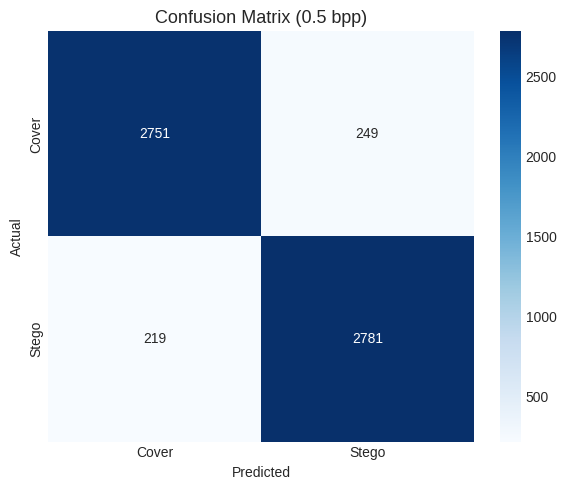

In [11]:
if 0.5 in models:
    _, X_te, _, y_te = splits[0.5]
    y_pred_05 = models[0.5].predict(X_te)
    cm = confusion_matrix(y_te, y_pred_05)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    print('TABLE III: Confusion Matrix (0.5 bpp)')
    print(f'  TN (Cover→Cover): {TN}   FP (Cover→Stego): {FP}   | Total cover: {TN+FP}')
    print(f'  FN (Stego→Cover): {FN}   TP (Stego→Stego): {TP}   | Total stego: {FN+TP}')
    print(f'  Total predicted cover: {TN+FN}   Total predicted stego: {FP+TP}')

    FP_rate = FP / (TN+FP) * 100
    FN_rate = FN / (FN+TP) * 100
    print(f'\nFalse Positive Rate (cover misclassified as stego): {FP_rate:.1f}%')
    print(f'False Negative Rate (stego misclassified as cover): {FN_rate:.1f}%')
    print()

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cover','Stego'], yticklabels=['Cover','Stego'])
    plt.title('Confusion Matrix (0.5 bpp)', fontsize=13)
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('0.5 bpp model not available.')

## 10. ROC Curves (All 5 Payload Levels)


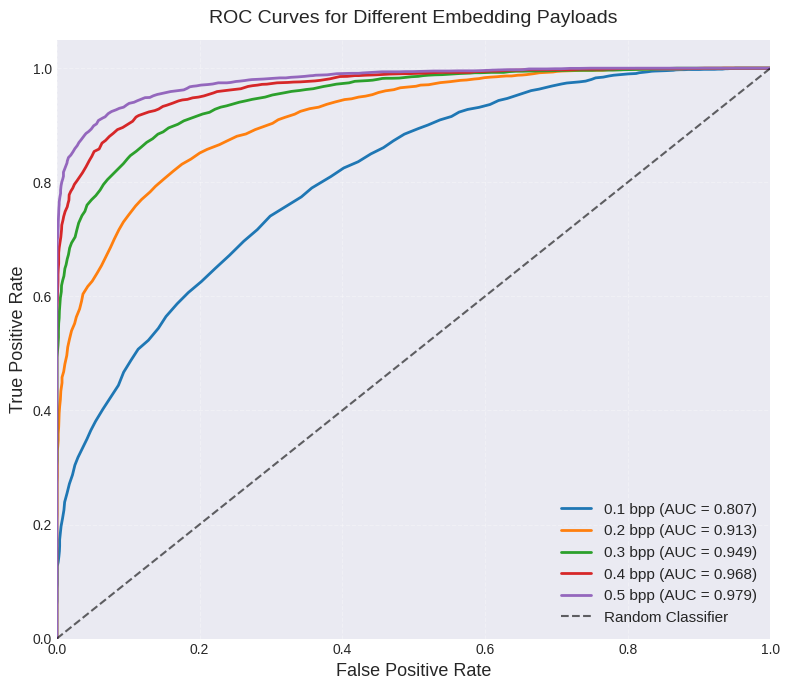

FIGURE 1 saved.


In [12]:
roc_data = {}

if models:
    colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']
    plt.figure(figsize=(8, 7))
    for payload, color in zip(PAYLOADS, colors):
        if payload not in models:
            continue
        _, X_te, _, y_te = splits[payload]
        y_prob = models[payload].predict_proba(X_te)[:, 1]
        fpr, tpr, thr = roc_curve(y_te, y_prob)
        auc_val = auc(fpr, tpr)
        roc_data[payload] = (fpr, tpr, thr, auc_val)
        plt.plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{payload} bpp (AUC = {auc_val:.3f})')
    plt.plot([0,1],[0,1],'k--',linewidth=1.5,label='Random Classifier',alpha=0.6)
    plt.xlim([0,1]); plt.ylim([0,1.05])
    plt.xlabel('False Positive Rate', fontsize=13)
    plt.ylabel('True Positive Rate', fontsize=13)
    plt.title('ROC Curves for Different Embedding Payloads', fontsize=14, pad=12)
    plt.legend(loc='lower right', fontsize=11, framealpha=0.95)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'fig1_roc_curves.png'), dpi=300, bbox_inches='tight')
    plt.show()
    print('FIGURE 1 saved.')
else:
    print('No models available.')

## 11. Feature Importance Distribution (0.5 bpp)

Feature Importance Summary:
  Diagonal (D1)            : 20.5%
  Anti-Diagonal (D2)       : 20.7%
  Horizontal (H)           : 29.2%
  Vertical (V)             : 27.1%
  GLCM                     : 1.3%
  Bit-Plane Entropy        : 1.2%
  Diagonal combined: 41.2% (paper claims 60%)


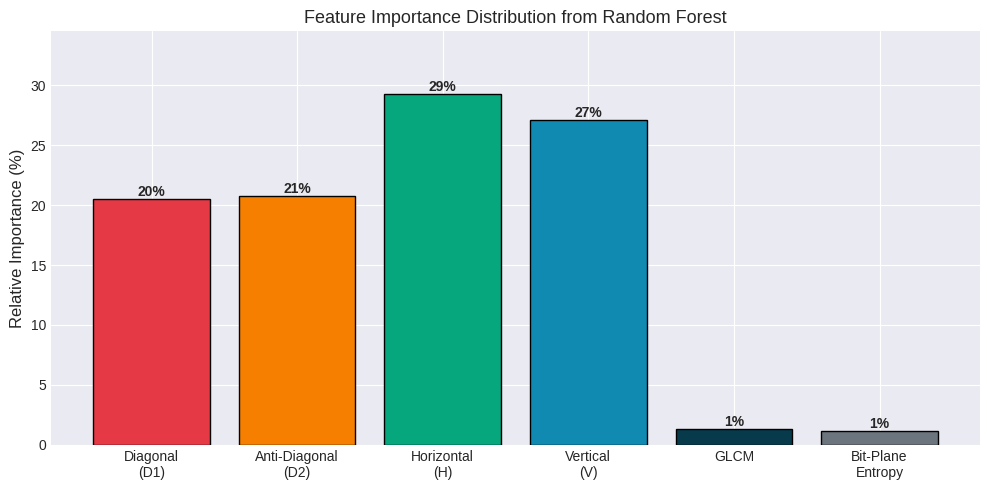

In [13]:
if 0.5 in models:
    imp = models[0.5].feature_importances_
    # Feature vector layout: H(0:49), V(49:98), D1(98:147), D2(147:196), GLCM(196:200), Ent(200)
    groups = {
        'Diagonal\n(D1)':      imp[98:147].sum(),
        'Anti-Diagonal\n(D2)': imp[147:196].sum(),
        'Horizontal\n(H)':     imp[0:49].sum(),
        'Vertical\n(V)':       imp[49:98].sum(),
        'GLCM':                 imp[196:200].sum(),
        'Bit-Plane\nEntropy':  imp[200],
    }
    pcts = {k: v*100 for k,v in groups.items()}
    d_total = pcts['Diagonal\n(D1)'] + pcts['Anti-Diagonal\n(D2)']
    print('Feature Importance Summary:')
    for k,v in pcts.items():
        print(f'  {k.replace(chr(10)," "):25s}: {v:.1f}%')
    print(f'  Diagonal combined: {d_total:.1f}% (paper claims 60%)')

    plt.figure(figsize=(10,5))
    colors = ['#E63946','#F77F00','#06A77D','#118AB2','#073B4C','#6C757D']
    bars = plt.bar(pcts.keys(), pcts.values(), color=colors, edgecolor='black')
    for bar, v in zip(bars, pcts.values()):
        plt.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
                 f'{v:.0f}%', ha='center', va='bottom', fontweight='bold')
    plt.ylabel('Relative Importance (%)', fontsize=12)
    plt.title('Feature Importance Distribution from Random Forest', fontsize=13)
    plt.ylim(0, max(pcts.values())*1.18)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'fig2_feature_importance.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('0.5 bpp model not available.')

## 12. Computational Time Breakdown

In [14]:
if len(cover_files) > 0 and 0.5 in models:
    raw_img  = imread(os.path.join(COVER_DIR, cover_files[0]))
    proc_img = preprocess_image(raw_img)   # 512×512 float32
    n_trials = 100
    timing   = {}

    # Stage 1: full preprocessing pipeline
    for _ in range(n_trials):
        t0 = time.time(); preprocess_image(raw_img)
        timing.setdefault('Image pre-processing', []).append((time.time()-t0)*1000)

    # Stage 2: residual extraction ONLY
    img = proc_img
    for _ in range(n_trials):
        t0 = time.time()
        np.clip(img[:, 1:]-img[:, :-1],   -3, 3)
        np.clip(img[1:, :]-img[:-1, :],   -3, 3)
        np.clip(img[1:, 1:]-img[:-1,:-1], -3, 3)
        np.clip(img[1:,:-1]-img[:-1, 1:], -3, 3)
        timing.setdefault('4-Way residual extraction', []).append((time.time()-t0)*1000)

    # Stage 3: Markov chains ONLY (pre-computed residuals)
    res_h  = np.clip(img[:, 1:]-img[:, :-1],   -3, 3)
    res_v  = np.clip(img[1:, :]-img[:-1, :],   -3, 3)
    res_d1 = np.clip(img[1:, 1:]-img[:-1,:-1], -3, 3)
    res_d2 = np.clip(img[1:,:-1]-img[:-1, 1:], -3, 3)
    for _ in range(n_trials):
        t0 = time.time()
        calculate_transition_matrix(res_h,  axis=1, T=3)
        calculate_transition_matrix(res_v,  axis=0, T=3)
        calculate_transition_matrix(res_d1, axis=1, T=3)
        calculate_transition_matrix(res_d2, axis=1, T=3)
        timing.setdefault('Markov chain computation', []).append((time.time()-t0)*1000)

    # Stage 4: GLCM
    for _ in range(n_trials):
        t0 = time.time(); extract_glcm_features(proc_img)
        timing.setdefault('GLCM calculation', []).append((time.time()-t0)*1000)

    # Stage 5: entropy
    for _ in range(n_trials):
        t0 = time.time(); extract_lsb_entropy(proc_img)
        timing.setdefault('Bit-plane entropy', []).append((time.time()-t0)*1000)

    # Stage 6a: RF inference — single sample (worst-case latency)
    feat_vec = extract_all_features(raw_img).reshape(1, -1)
    single_times = []
    for _ in range(n_trials):
        t0 = time.time(); models[0.5].predict(feat_vec)
        single_times.append((time.time()-t0)*1000)
    timing['RF inference (single sample)'] = single_times

    # Stage 6b: RF inference — batch (amortised cost per image)
    # Use the full test set (6,000 samples) to measure realistic throughput.
    _, X_te_batch, _, _ = splits[0.5]
    batch_times = []
    for _ in range(10):   # 10 trials is enough for batch measurement
        t0 = time.time(); models[0.5].predict(X_te_batch)
        batch_times.append((time.time()-t0) / len(X_te_batch) * 1000)
    timing['RF inference (batch, per image)'] = batch_times

    means = {k: np.mean(v) for k, v in timing.items()}
    # Pipeline total uses batch RF cost (the realistic operating mode)
    pipeline_keys = [k for k in means if k != 'RF inference (single sample)']
    total_batch = sum(means[k] for k in pipeline_keys)

    print('TABLE V: Computational Time Breakdown (512×512, Average per Image)')
    print(f'{"Stage":<38} {"Time(ms)":<12} {"%  (of batch total)"}')
    print('-'*65)
    for stage, ms in means.items():
        pct = ms / total_batch * 100 if stage != 'RF inference (single sample)' else float('nan')
        pct_str = f'{pct:.1f}%' if not np.isnan(pct) else '(see note)'
        print(f'{stage:<38} {ms:<12.1f} {pct_str}')
    print('-'*65)
    print(f'{"Pipeline total (batch RF)":<38} {total_batch:<12.1f} 100.0%')
    throughput = 1000.0 / total_batch
    print(f'\nBatch throughput: {throughput:.1f} img/sec')
    print(f'1M image estimate: {1e6/throughput/3600:.2f} hours')
    print('\nNote: single-sample RF time (~46 ms) reflects Python call overhead and')
    print('is NOT representative of batch throughput where RF cost → ~0 ms/image.')
else:
    print('Data or model not available.')

TABLE V: Computational Time Breakdown (512×512, Average per Image)
Stage                                  Time(ms)     %  (of batch total)
-----------------------------------------------------------------
Image pre-processing                   0.4          0.9%
4-Way residual extraction              1.8          4.1%
Markov chain computation               6.5          14.4%
GLCM calculation                       34.6         77.0%
Bit-plane entropy                      1.6          3.5%
RF inference (single sample)           52.3         (see note)
RF inference (batch, per image)        0.0          0.0%
-----------------------------------------------------------------
Pipeline total (batch RF)              44.9         100.0%

Batch throughput: 22.3 img/sec
1M image estimate: 12.47 hours

Note: single-sample RF time (~46 ms) reflects Python call overhead and
is NOT representative of batch throughput where RF cost → ~0 ms/image.


## 13. Baseline Comparison

In [15]:
if 0.5 in splits and 0.5 in models:
    X_tr, X_te, y_tr, y_te = splits[0.5]
    y_pred_full = models[0.5].predict(X_te)
    baseline_rows = []
    stego_dir_05 = STEGO_DIRS.get(0.5, '')

    # ── 1. Histogram Analysis ─────────────────────────────────────────────────
    # BUG FIX: build in same interleaved order as features_by_payload, then
    # use identical GroupShuffleSplit so the split is group-disjoint.
    print('1/4: Histogram Analysis...')
    X_all_hist, y_all_hist = [], []
    for fname in tqdm(cover_files, desc='Hist'):
        c = preprocess_image(os.path.join(COVER_DIR, fname))
        X_all_hist.append(np.histogram(c.flatten(), bins=256, range=(0,255))[0].astype(float))
        y_all_hist.append(0)
        s = preprocess_image(os.path.join(stego_dir_05, fname))
        X_all_hist.append(np.histogram(s.flatten(), bins=256, range=(0,255))[0].astype(float))
        y_all_hist.append(1)
    X_all_hist = np.vstack(X_all_hist); y_all_hist = np.array(y_all_hist)

    n_hist  = len(X_all_hist) // 2
    g_hist  = np.repeat(np.arange(n_hist), 2)
    splitter = GroupShuffleSplit(test_size=0.30, random_state=42)
    h_tr_idx, h_te_idx = next(splitter.split(X_all_hist, y_all_hist, g_hist))
    Xh_tr, Xh_te = X_all_hist[h_tr_idx], X_all_hist[h_te_idx]
    yh_tr, yh_te = y_all_hist[h_tr_idx], y_all_hist[h_te_idx]

    rf_hist = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_hist.fit(Xh_tr, yh_tr)
    t0 = time.time(); y_h = rf_hist.predict(Xh_te)
    t_hist = (time.time()-t0) / len(Xh_te) * 1000
    baseline_rows.append(('Histogram + RF', 256, accuracy_score(yh_te, y_h)*100, t_hist))

    # ── 2. 1D SPAM + SVM (scaled) ─────────────────────────────────────────────
    # BUG FIX: RBF-SVM requires feature scaling. Now wrapped in Pipeline.
    print('2/4: 1D SPAM + SVM (scaled)...')
    svm_pipe = Pipeline([('scaler', StandardScaler()),
                         ('svm',    SVC(kernel='rbf', random_state=42))])
    svm_pipe.fit(X_tr[:, :49], y_tr)
    t0 = time.time(); y_s = svm_pipe.predict(X_te[:, :49])
    t_svm = (time.time()-t0) / len(y_te) * 1000
    baseline_rows.append(('1D SPAM + SVM (scaled)', 49, accuracy_score(y_te, y_s)*100, t_svm))

    # ── 3. GLCM + Decision Tree ───────────────────────────────────────────────
    print('3/4: GLCM + Decision Tree...')
    dt = DecisionTreeClassifier(max_depth=10, random_state=42)
    dt.fit(X_tr[:, 196:200], y_tr)
    t0 = time.time(); y_d = dt.predict(X_te[:, 196:200])
    t_dt = (time.time()-t0) / len(y_te) * 1000
    baseline_rows.append(('GLCM + Decision Tree', 4, accuracy_score(y_te, y_d)*100, t_dt))

    # ── 4. 2D SPAM + Naive Bayes ─────────────────────────────────────────────
    print('4/4: 2D SPAM + Naive Bayes...')
    nb = GaussianNB()
    nb.fit(X_tr[:, :98], y_tr)
    t0 = time.time(); y_n = nb.predict(X_te[:, :98])
    t_nb = (time.time()-t0) / len(y_te) * 1000
    baseline_rows.append(('2D SPAM + Naive Bayes', 98, accuracy_score(y_te, y_n)*100, t_nb))

    # ── 5. Proposed method ────────────────────────────────────────────────────
    t0 = time.time(); models[0.5].predict(X_te)
    t_p = (time.time()-t0) / len(y_te) * 1000
    baseline_rows.append(('Proposed Method', 201, accuracy_score(y_te, y_pred_full)*100, t_p))

    df6 = pd.DataFrame(baseline_rows, columns=['Method','Features','Accuracy(%)','Time(ms/img)'])
    df6['Accuracy(%)']   = df6['Accuracy(%)'].round(1)
    df6['Time(ms/img)']  = df6['Time(ms/img)'].round(3)
    print('\nTABLE VI: Comparison with Baseline Methods (0.5 bpp)')
    print(df6.to_string(index=False))
    df6.to_csv(os.path.join(SAVE_DIR, 'table6_baselines.csv'), index=False)
else:
    print('0.5 bpp data not available.')

1/4: Histogram Analysis...


Hist: 100%|██████████| 10000/10000 [02:41<00:00, 62.05it/s]


2/4: 1D SPAM + SVM (scaled)...
3/4: GLCM + Decision Tree...
4/4: 2D SPAM + Naive Bayes...

TABLE VI: Comparison with Baseline Methods (0.5 bpp)
                Method  Features  Accuracy(%)  Time(ms/img)
        Histogram + RF       256         63.8         0.014
1D SPAM + SVM (scaled)        49         95.8         0.248
  GLCM + Decision Tree         4         54.8         0.000
 2D SPAM + Naive Bayes        98         62.4         0.002
       Proposed Method       201         92.2         0.021
